In [50]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt


In [53]:


class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, act_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.net(x)

    def get_dist(self, x):
        return Categorical(self.forward(x))


class ValueNet(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def flat_params(model):
    return torch.cat([p.view(-1) for p in model.parameters()])


def assign_params(model, flat_weights):
    idx = 0
    for p in model.parameters():
        numel = p.numel()
        p.data.copy_(flat_weights[idx:idx + numel].view_as(p))
        idx += numel


def conjugate_gradient(Av_func, b, nsteps, tol=1e-10):
    x = torch.zeros_like(b)
    r = b.clone()
    p = b.clone()
    r_dot_old = torch.dot(r, r)
    for _ in range(nsteps):
        Avp = Av_func(p)
        alpha = r_dot_old / (torch.dot(p, Avp) + 1e-8)
        x += alpha * p
        r -= alpha * Avp
        r_dot_new = torch.dot(r, r)
        if r_dot_new < tol:
            break
        p = r + (r_dot_new / r_dot_old) * p
        r_dot_old = r_dot_new
    return x


def surrogate_loss(pi, old_pi, obs, act, adv):
    dist = pi.get_dist(obs)
    old_dist = old_pi.get_dist(obs)
    ratio = torch.exp(dist.log_prob(act) - old_dist.log_prob(act))
    return (ratio * adv).mean()


def kl_div(pi, old_pi, obs):
    dist = pi.get_dist(obs)
    old_dist = old_pi.get_dist(obs)
    return torch.distributions.kl.kl_divergence(old_dist, dist).mean()


def hessian_vector_product(pi, obs, damping_coeff, v):
    kl = kl_div(pi, deepcopy(pi), obs)
    grads = torch.autograd.grad(kl, pi.parameters(), create_graph=True)
    flat_grad_kl = torch.cat([g.view(-1) for g in grads])
    kl_v = torch.dot(flat_grad_kl, v)
    grad_grad = torch.autograd.grad(kl_v, pi.parameters())
    flat_grad_grad = torch.cat([g.contiguous().view(-1) for g in grad_grad])
    return flat_grad_grad + damping_coeff * v


def collect_trajectories(policy, env, batch_size, gamma):
    obs_list, act_list, logp_list = [], [], []
    total_rewards = []
    rewards_flat = []
    returns_flat = []

    obs, _ = env.reset()
    total_steps = 0

    while total_steps < batch_size:
        episode_obs, episode_acts, episode_rews = [], [], []
        done = False

        while not done and total_steps < batch_size:
            obs_tensor = torch.from_numpy(obs).float().unsqueeze(0)
            dist = policy.get_dist(obs_tensor)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_obs, reward, done, truncated, _ = env.step(action.item())
            done = done or truncated

            episode_obs.append(obs)
            episode_acts.append(action.item())
            episode_rews.append(reward)
            logp_list.append(log_prob.item())

            obs = next_obs
            total_steps += 1

        G = 0
        returns = []
        for r in reversed(episode_rews):
            G = r + gamma * G
            returns.insert(0, G)

        obs_list.extend(episode_obs)
        act_list.extend(episode_acts)
        rewards_flat.extend(episode_rews)
        returns_flat.extend(returns)
        total_rewards.append(sum(episode_rews))

        obs, _ = env.reset()

    return obs_list, act_list, logp_list, rewards_flat, returns_flat, total_rewards


def train_trpo(
    env_name='CartPole-v1',
    gamma=0.99,
    max_kl=1e-2,
    damping=1e-1,
    cg_iters=10,
    epochs=200,
    batch_size=5000,
    vf_lr=1e-2,
    vf_iters=5,
    render=False
):
    env = gym.make(env_name)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    policy = PolicyNet(obs_dim, act_dim).to(device)
    value_fn = ValueNet(obs_dim).to(device)
    # value_optimizer = optim.Adam(value_fn.parameters(), lr=vf_lr)
    value_optimizer = optim.SGD(value_fn.parameters(), lr=vf_lr)

    all_rewards = []

    for epoch in range(epochs):
        obs_list, act_list, logp_list, rewards, returns, ep_rewards = collect_trajectories(policy, env, batch_size, gamma)

        obs_tensor = torch.from_numpy(np.array(obs_list)).float().to(device)
        act_tensor = torch.tensor(act_list, dtype=torch.int64).to(device)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)

        with torch.no_grad():
            values = value_fn(obs_tensor)
            adv = returns - values
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        for _ in range(vf_iters):
            value_loss = ((value_fn(obs_tensor) - returns) ** 2).mean()
            value_optimizer.zero_grad()
            value_loss.backward()
            value_optimizer.step()

        old_policy = deepcopy(policy)
        old_params = flat_params(policy).detach()

        loss = surrogate_loss(policy, old_policy, obs_tensor, act_tensor, adv)
        grad = torch.autograd.grad(loss, policy.parameters())
        grad_flat = torch.cat([g.view(-1) for g in grad]).detach()

        def hvp(v): return hessian_vector_product(policy, obs_tensor, damping, v)
        step_dir = conjugate_gradient(hvp, grad_flat, cg_iters)
        shs = 0.5 * (step_dir * hvp(step_dir)).sum()
        lm = torch.sqrt(shs / max_kl)
        full_step = step_dir / lm

        def set_and_eval(step):
            new_params = old_params + step
            assign_params(policy, new_params)
            new_loss = surrogate_loss(policy, old_policy, obs_tensor, act_tensor, adv)
            new_kl = kl_div(policy, old_policy, obs_tensor)
            return new_loss, new_kl

        for i in range(10):
            step = 0.9 ** i * full_step
            new_loss, kl = set_and_eval(step)
            if kl <= max_kl and new_loss >= loss:
                break
            if i == 9:
                assign_params(policy, old_params)

        avg_reward = np.mean(ep_rewards)
        all_rewards.extend(ep_rewards)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}: Average Reward = {avg_reward:.2f}")

        if render:
            env.render()

    env.close()
    return all_rewards



Epoch 10: Average Reward = 277.78
Epoch 20: Average Reward = 416.67
Epoch 30: Average Reward = 500.00
Epoch 40: Average Reward = 416.67
Epoch 50: Average Reward = 500.00
Epoch 60: Average Reward = 500.00
Epoch 70: Average Reward = 416.67
Epoch 80: Average Reward = 500.00
Epoch 90: Average Reward = 500.00
Epoch 100: Average Reward = 500.00


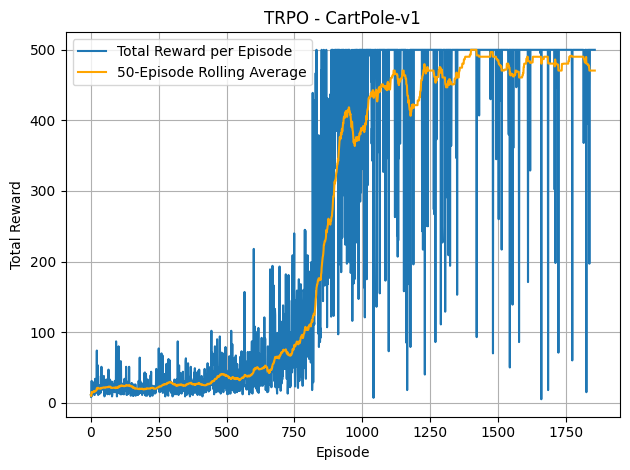

In [54]:

if __name__ == "__main__":
    all_rewards = train_trpo(epochs=100)

    # 📈 Plot rewards after training
    window_size = 50
    rolling_avg = [np.mean(all_rewards[max(0, i - window_size):(i + 1)]) for i in range(len(all_rewards))]

    plt.plot(all_rewards, label='Total Reward per Episode')
    plt.plot(rolling_avg, label=f'{window_size}-Episode Rolling Average', color='orange')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('TRPO - CartPole-v1')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
